# Banking Customer Behaviour & Loan Risk Analysis

## Business Context

A retail bank serves customers across multiple districts while managing accounts, transactions, cards, standing orders, and loans. These activities generate large amounts of operational data, but individual records alone do not explain which customers are valuable, where financial risk is concentrated, or how borrowing behaviour differs across customer groups.

This analysis brings those records together to examine customer behaviour and loan performance from a business perspective. The focus is not simply on reporting historical activity, but on identifying patterns that could help the bank understand its customers, recognise potential loan risk, and make more informed decisions.

## Analysis Objectives

The analysis is structured around three connected areas of the bank's operations:

- Understand how customers use their accounts and how transaction behaviour varies across the customer base.
- Examine the loan portfolio to identify repayment patterns and areas where credit risk may be concentrated.
- Explore whether customer, account, transaction, and regional characteristics help explain differences in loan outcomes.

These findings will later be brought together to distinguish normal customer behaviour from patterns that may deserve closer business attention.

# 1. Project Architecture Diagram

The project follows a structured workflow that transforms raw banking data into meaningful business insights through SQL analysis and Python-based validation.

```text
                   Berka Banking Dataset
        (account, client, loan, trans, etc.)
                           │
                           ▼
                  SQLite Database Setup
                           │
                           ▼
              Data Validation & Preparation
                           │
                           ▼
                SQL Business Analysis
      (Customer, Loan, Transaction & Risk)
                           │
                           ▼
            Python Exploratory Data Analysis
              (Charts & Visual Validation)
                           │
                           ▼
         Business Insights & Key Findings
                           │
                           ▼
      Business Recommendations & Final Summary
```

# 2. Dataset Overview

The Berka Banking dataset consists of eight relational tables that capture customer, account, loan, and transaction information. These datasets were integrated using SQL to perform business analysis and later validated through Python Exploratory Data Analysis (EDA).

| Dataset | Description |
|---------|-------------|
| `account.csv` | Stores customer account information, including account creation details and associated districts. |
| `client.csv` | Contains customer demographic information such as birth number and gender. |
| `disp.csv` | Maps customers to their respective bank accounts and defines account ownership. |
| `loan.csv` | Stores loan details, repayment status, loan amount, and contract duration. |
| `trans.csv` | Contains complete transaction history, including deposits, withdrawals, balances, and transaction types. |
| `order.csv` | Records standing orders and scheduled payment instructions linked to customer accounts. |
| `card.csv` | Stores bank card information associated with customer accounts. |
| `district.csv` | Provides regional and demographic information for each district, supporting geographical analysis. |

# 2.1 Data Access & SQL Setup

In [61]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../sql/berka_bank.db")

## 3. Database Overview & Data Quality Check

Before analysing customer behaviour or loan risk, the database is first reviewed for table structure, record coverage, missing values, and possible duplicate records. This step helps identify data limitations early and prevents unreliable patterns from carrying into the later analysis.

### Table Size Overview

In [62]:
query = """
SELECT
    'account' AS table_name,
    COUNT(*) AS total_rows
FROM account

UNION ALL
SELECT 'card', COUNT(*) FROM card

UNION ALL
SELECT 'client', COUNT(*) FROM client

UNION ALL
SELECT 'disp', COUNT(*) FROM disp

UNION ALL
SELECT 'district', COUNT(*) FROM district

UNION ALL
SELECT 'loan', COUNT(*) FROM loan

UNION ALL
SELECT 'order', COUNT(*) FROM "order"

UNION ALL
SELECT 'trans', COUNT(*) FROM trans;
"""

pd.read_sql(query, conn)

,table_name,total_rows
0,account,4500
1,card,892
2,client,5369
3,disp,5369
4,district,77
5,loan,682
6,order,6471
7,trans,1056320


### Duplicate ID Check

In [63]:
query = """
SELECT 'account' AS table_name,
       COUNT(*) - COUNT(DISTINCT account_id) AS duplicate_ids
FROM account

UNION ALL
SELECT 'card',
       COUNT(*) - COUNT(DISTINCT card_id)
FROM card

UNION ALL
SELECT 'client',
       COUNT(*) - COUNT(DISTINCT client_id)
FROM client

UNION ALL
SELECT 'disp',
       COUNT(*) - COUNT(DISTINCT disp_id)
FROM disp

UNION ALL
SELECT 'district',
       COUNT(*) - COUNT(DISTINCT A1)
FROM district

UNION ALL
SELECT 'loan',
       COUNT(*) - COUNT(DISTINCT loan_id)
FROM loan

UNION ALL
SELECT 'order',
       COUNT(*) - COUNT(DISTINCT order_id)
FROM "order"

UNION ALL
SELECT 'trans',
       COUNT(*) - COUNT(DISTINCT trans_id)
FROM trans;
"""

pd.read_sql(query, conn)

,table_name,duplicate_ids
0,account,0
1,card,0
2,client,0
3,disp,0
4,district,0
5,loan,0
6,order,0
7,trans,0


### Table Inspection and Missing Value Check

#### `Account Information`

In [64]:
query = """
SELECT *
FROM account
LIMIT 5;
"""

pd.read_sql(query, conn)

,account_id,district_id,frequency,date
0,576,55,POPLATEK MESICNE,930101
1,3818,74,POPLATEK MESICNE,930101
2,704,55,POPLATEK MESICNE,930101
3,2378,16,POPLATEK MESICNE,930101
4,2632,24,POPLATEK MESICNE,930102


In [65]:
query = """
SELECT
    SUM(CASE WHEN account_id IS NULL THEN 1 ELSE 0 END) AS account_id_nulls,
    SUM(CASE WHEN district_id IS NULL THEN 1 ELSE 0 END) AS district_id_nulls,
    SUM(CASE WHEN frequency IS NULL THEN 1 ELSE 0 END) AS frequency_nulls,
    SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS date_nulls
FROM account;
"""

pd.read_sql(query, conn)

,account_id_nulls,district_id_nulls,frequency_nulls,date_nulls
0,0,0,0,0


### `Card Information`

In [66]:
query = """
SELECT *
FROM card
LIMIT 5;
"""

pd.read_sql(query, conn)

,card_id,disp_id,type,issued
0,1005,9285,classic,931107 00:00:00
1,104,588,classic,940119 00:00:00
2,747,4915,classic,940205 00:00:00
3,70,439,classic,940208 00:00:00
4,577,3687,classic,940215 00:00:00


In [67]:
query = """
SELECT
    SUM(CASE WHEN card_id IS NULL THEN 1 ELSE 0 END) AS card_id_nulls,
    SUM(CASE WHEN disp_id IS NULL THEN 1 ELSE 0 END) AS disp_id_nulls,
    SUM(CASE WHEN type IS NULL THEN 1 ELSE 0 END) AS type_nulls,
    SUM(CASE WHEN issued IS NULL THEN 1 ELSE 0 END) AS issued_nulls
FROM card;
"""

pd.read_sql(query, conn)

,card_id_nulls,disp_id_nulls,type_nulls,issued_nulls
0,0,0,0,0


#### `Client Information`

In [68]:
query = """
SELECT *
FROM client
LIMIT 5;
"""

pd.read_sql(query, conn)

,client_id,birth_number,district_id
0,1,706213,18
1,2,450204,1
2,3,406009,1
3,4,561201,5
4,5,605703,5


In [69]:
query = """
SELECT
    SUM(CASE WHEN client_id IS NULL THEN 1 ELSE 0 END) AS client_id_nulls,
    SUM(CASE WHEN birth_number IS NULL THEN 1 ELSE 0 END) AS birth_number_nulls,
    SUM(CASE WHEN district_id IS NULL THEN 1 ELSE 0 END) AS district_id_nulls
FROM client;
"""

pd.read_sql(query, conn)

,client_id_nulls,birth_number_nulls,district_id_nulls
0,0,0,0


#### `Disposition Information`

In [70]:
query = """
SELECT *
FROM disp
LIMIT 5;
"""

pd.read_sql(query, conn)

,disp_id,client_id,account_id,type
0,1,1,1,OWNER
1,2,2,2,OWNER
2,3,3,2,DISPONENT
3,4,4,3,OWNER
4,5,5,3,DISPONENT


In [71]:
query = """
SELECT
    SUM(CASE WHEN disp_id IS NULL THEN 1 ELSE 0 END) AS disp_id_nulls,
    SUM(CASE WHEN client_id IS NULL THEN 1 ELSE 0 END) AS client_id_nulls,
    SUM(CASE WHEN account_id IS NULL THEN 1 ELSE 0 END) AS account_id_nulls,
    SUM(CASE WHEN type IS NULL THEN 1 ELSE 0 END) AS type_nulls
FROM disp;
"""

pd.read_sql(query, conn)

,disp_id_nulls,client_id_nulls,account_id_nulls,type_nulls
0,0,0,0,0


#### `District Information`

In [72]:
query = """
SELECT *
FROM district
LIMIT 5;
"""

pd.read_sql(query, conn)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.29,0.43,167,85677,99107
1,2,Benesov,central Bohemia,88884,80,26,6,2,5,46.7,8507,1.67,1.85,132,2159,2674
2,3,Beroun,central Bohemia,75232,55,26,4,1,5,41.7,8980,1.95,2.21,111,2824,2813
3,4,Kladno,central Bohemia,149893,63,29,6,2,6,67.4,9753,4.64,5.05,109,5244,5892
4,5,Kolin,central Bohemia,95616,65,30,4,1,6,51.4,9307,3.85,4.43,118,2616,3040


In [73]:
query = """
SELECT
    SUM(CASE WHEN A1 IS NULL THEN 1 ELSE 0 END) AS A1_nulls,
    SUM(CASE WHEN A2 IS NULL THEN 1 ELSE 0 END) AS A2_nulls,
    SUM(CASE WHEN A3 IS NULL THEN 1 ELSE 0 END) AS A3_nulls,
    SUM(CASE WHEN A4 IS NULL THEN 1 ELSE 0 END) AS A4_nulls,
    SUM(CASE WHEN A5 IS NULL THEN 1 ELSE 0 END) AS A5_nulls,
    SUM(CASE WHEN A6 IS NULL THEN 1 ELSE 0 END) AS A6_nulls,
    SUM(CASE WHEN A7 IS NULL THEN 1 ELSE 0 END) AS A7_nulls,
    SUM(CASE WHEN A8 IS NULL THEN 1 ELSE 0 END) AS A8_nulls,
    SUM(CASE WHEN A9 IS NULL THEN 1 ELSE 0 END) AS A9_nulls,
    SUM(CASE WHEN A10 IS NULL THEN 1 ELSE 0 END) AS A10_nulls,
    SUM(CASE WHEN A11 IS NULL THEN 1 ELSE 0 END) AS A11_nulls,
    SUM(CASE WHEN A12 IS NULL THEN 1 ELSE 0 END) AS A12_nulls,
    SUM(CASE WHEN A13 IS NULL THEN 1 ELSE 0 END) AS A13_nulls,
    SUM(CASE WHEN A14 IS NULL THEN 1 ELSE 0 END) AS A14_nulls,
    SUM(CASE WHEN A15 IS NULL THEN 1 ELSE 0 END) AS A15_nulls,
    SUM(CASE WHEN A16 IS NULL THEN 1 ELSE 0 END) AS A16_nulls
FROM district;
"""

pd.read_sql(query, conn)

,A1_nulls,A2_nulls,A3_nulls,A4_nulls,A5_nulls,A6_nulls,A7_nulls,A8_nulls,A9_nulls,A10_nulls,A11_nulls,A12_nulls,A13_nulls,A14_nulls,A15_nulls,A16_nulls
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### `Loan Information`

In [74]:
query = """
SELECT *
FROM loan
LIMIT 5;
"""

pd.read_sql(query, conn)

,loan_id,account_id,date,amount,duration,payments,status
0,5314,1787,930705,96396,12,8033.0,B
1,5316,1801,930711,165960,36,4610.0,A
2,6863,9188,930728,127080,60,2118.0,A
3,5325,1843,930803,105804,36,2939.0,A
4,7240,11013,930906,274740,60,4579.0,A


In [75]:
query = """
SELECT
    SUM(CASE WHEN loan_id IS NULL THEN 1 ELSE 0 END) AS loan_id_nulls,
    SUM(CASE WHEN account_id IS NULL THEN 1 ELSE 0 END) AS account_id_nulls,
    SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS date_nulls,
    SUM(CASE WHEN amount IS NULL THEN 1 ELSE 0 END) AS amount_nulls,
    SUM(CASE WHEN duration IS NULL THEN 1 ELSE 0 END) AS duration_nulls,
    SUM(CASE WHEN payments IS NULL THEN 1 ELSE 0 END) AS payments_nulls,
    SUM(CASE WHEN status IS NULL THEN 1 ELSE 0 END) AS status_nulls
FROM loan;
"""

pd.read_sql(query, conn)

,loan_id_nulls,account_id_nulls,date_nulls,amount_nulls,duration_nulls,payments_nulls,status_nulls
0,0,0,0,0,0,0,0


#### `Standing Order Information`

In [76]:
query = """
SELECT *
FROM "order"
LIMIT 5;
"""

pd.read_sql(query, conn)

,order_id,account_id,bank_to,account_to,amount,k_symbol
0,29401,1,YZ,87144583,2452.0,SIPO
1,29402,2,ST,89597016,3372.7,UVER
2,29403,2,QR,13943797,7266.0,SIPO
3,29404,3,WX,83084338,1135.0,SIPO
4,29405,3,CD,24485939,327.0,


In [77]:
query = """
SELECT
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS order_id_nulls,
    SUM(CASE WHEN account_id IS NULL THEN 1 ELSE 0 END) AS account_id_nulls,
    SUM(CASE WHEN bank_to IS NULL THEN 1 ELSE 0 END) AS bank_to_nulls,
    SUM(CASE WHEN account_to IS NULL THEN 1 ELSE 0 END) AS account_to_nulls,
    SUM(CASE WHEN amount IS NULL THEN 1 ELSE 0 END) AS amount_nulls,
    SUM(CASE WHEN k_symbol IS NULL THEN 1 ELSE 0 END) AS k_symbol_nulls
FROM "order";
"""

pd.read_sql(query, conn)

,order_id_nulls,account_id_nulls,bank_to_nulls,account_to_nulls,amount_nulls,k_symbol_nulls
0,0,0,0,0,0,0


#### `Transaction Information`

In [78]:
query = """
SELECT *
FROM trans
LIMIT 5;
"""

pd.read_sql(query, conn)

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,None,None,None
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,None,None,None
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,None,None,None
3,1117247,3818,930101,PRIJEM,VKLAD,600.0,600.0,None,None,None
4,579373,1972,930102,PRIJEM,VKLAD,400.0,400.0,None,None,None


In [79]:
query = """
SELECT
    SUM(CASE WHEN trans_id IS NULL THEN 1 ELSE 0 END) AS trans_id_nulls,
    SUM(CASE WHEN account_id IS NULL THEN 1 ELSE 0 END) AS account_id_nulls,
    SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS date_nulls,
    SUM(CASE WHEN type IS NULL THEN 1 ELSE 0 END) AS type_nulls,
    SUM(CASE WHEN operation IS NULL THEN 1 ELSE 0 END) AS operation_nulls,
    SUM(CASE WHEN amount IS NULL THEN 1 ELSE 0 END) AS amount_nulls,
    SUM(CASE WHEN balance IS NULL THEN 1 ELSE 0 END) AS balance_nulls,
    SUM(CASE WHEN k_symbol IS NULL THEN 1 ELSE 0 END) AS k_symbol_nulls,
    SUM(CASE WHEN bank IS NULL THEN 1 ELSE 0 END) AS bank_nulls,
    SUM(CASE WHEN account IS NULL THEN 1 ELSE 0 END) AS account_nulls
FROM trans;
"""

pd.read_sql(query, conn)

,trans_id_nulls,account_id_nulls,date_nulls,type_nulls,operation_nulls,amount_nulls,balance_nulls,k_symbol_nulls,bank_nulls,account_nulls
0,0,0,0,0,183114,0,0,481881,782812,760931


### Initial Data Quality Findings
The table-level checks showed complete values across the account, card, client, disposition, district, loan, and standing-order tables in the fields reviewed. The transaction table was the only table where missing values appeared in several columns, including operation, k_symbol, bank, and account. Since these fields describe different parts of a transaction, their missing values need to be understood in context before any cleaning decision is made.

## 3.1 Transaction Missing-Value Investigation
       k_symbol distribution

In [80]:
query = """
SELECT
    k_symbol,
    COUNT(*) AS transaction_count
FROM trans
GROUP BY k_symbol
ORDER BY transaction_count DESC;
"""

pd.read_sql(query, conn)

,k_symbol,transaction_count
0,NaN,481881
1,UROK,183114
2,SLUZBY,155832
3,SIPO,118065
4,,53433
5,DUCHOD,30338
6,POJISTNE,18500
7,UVER,13580
8,SANKC. UROK,1577


### `operation` distribution

In [81]:
query = """
SELECT
    operation,
    COUNT(*) AS transaction_count
FROM trans
GROUP BY operation
ORDER BY transaction_count DESC;
"""

pd.read_sql(query, conn)

,operation,transaction_count
0,VYBER,434918
1,PREVOD NA UCET,208283
2,NaN,183114
3,VKLAD,156743
4,PREVOD Z UCTU,65226
5,VYBER KARTOU,8036


### `bank` distribution

In [82]:
query = """
SELECT
    bank,
    COUNT(*) AS transaction_count
FROM trans
GROUP BY bank
ORDER BY transaction_count DESC;
"""

pd.read_sql(query, conn)

,bank,transaction_count
0,NaN,782812
1,QR,22285
2,AB,21720
3,ST,21711
4,YZ,21582
5,GH,21499
6,EF,21293
7,KL,21234
8,UV,21167
9,OP,21094


### `account` distribution

In [83]:
query = """
SELECT
    account,
    COUNT(*) AS transaction_count
FROM trans
GROUP BY account
ORDER BY transaction_count DESC;
"""

pd.read_sql(query, conn)

,account,transaction_count
0,NaN,760931
1,0.0,21881
2,66487163.0,140
3,13943797.0,130
4,95437645.0,95
...,...,...
7661,50500750.0,1
7662,29951918.0,1
7663,22888767.0,1
7664,22070646.0,1


### Investigation of Zero Account Values

In [84]:
query = """
SELECT
    type,
    operation,
    COUNT(*) AS transaction_count
FROM trans
WHERE account = 0
GROUP BY type, operation
ORDER BY transaction_count DESC;
"""

pd.read_sql(query, conn)

,type,operation,transaction_count
0,VYDAJ,VYBER,13845
1,VYDAJ,VYBER KARTOU,8036


### 3.2 Transaction Missing-Value Investigation Summary

The transaction table contains missing values mainly in `operation`, `k_symbol`, `bank`, and `account`. Further investigation indicates that these missing values are largely related to the nature of specific transaction types rather than random data-quality issues.

- `operation` contains 183,114 missing values.
- `k_symbol` contains 481,881 missing values and also includes blank values.
- `bank` contains 782,812 missing values.
- `account` contains 760,931 missing values.
- The `account` column also contains 21,881 records with a value of `0`.
- Investigation of these zero-account records showed that all of them belong to withdrawal transactions: 13,845 cash withdrawals (`VYBER`) and 8,036 card withdrawals (`VYBER KARTOU`).
- Therefore, the zero account values are treated as contextual placeholders where an external destination account is not applicable, rather than as ordinary account numbers.

These values will not be removed or imputed at this stage. They will be retained and interpreted according to transaction context during the analysis.

## 3.3 Data Quality Summary

Across the eight tables, identifier checks returned no duplicates, and the account, card, client, disposition, district, loan, and standing-order records were complete in the fields reviewed. 

Transaction data needed a closer look because some attributes are only populated for certain kinds of activity. These missing values were investigated separately to understand their transaction context before deciding how they should be handled. A second issue is readability: dates are stored in compact formats, several categories retain Czech labels, and the district table uses A1–A16 as column names.

 These fields need to be interpreted and prepared before they enter customer, transaction, or loan-risk analysis. At this point, the underlying records remain intact, with the identified formatting and labeling issues carried forward for controlled preparation.

## 4. Data Preparation & Feature Engineering

The quality checks identified a few fields that need preparation before the analysis begins. Dates will be converted into usable formats, coded labels will be made easier to interpret, and the district fields will be given meaningful names. New fields will only be created where they are useful for the customer, transaction, or loan analysis that follows.

## 4.1 Date Preparation

In [85]:
query = """
SELECT m.name AS table_name, p.name AS column_name
FROM sqlite_master AS m
JOIN pragma_table_info(m.name) AS p
WHERE m.type = 'table'
  AND (
      LOWER(p.name) LIKE '%date%'
      OR LOWER(p.name) LIKE '%issued%'
  )
ORDER BY m.name;
"""

pd.read_sql(query, conn)

,table_name,column_name
0,account,date
1,card,issued
2,loan,date
3,trans,date


The date-field check identified four date-related columns across the database: `account.date`, `card.issued`, `loan.date`, and `trans.date`. These fields will be reviewed and converted into consistent date formats before they are used in the analysis.

In [86]:
query = """
SELECT 'account' AS table_name, CAST(date AS TEXT) AS date_value
FROM account
LIMIT 5;

"""

pd.read_sql(query, conn)

,table_name,date_value
0,account,930101
1,account,930101
2,account,930101
3,account,930101
4,account,930102


In [87]:
query = """
SELECT 'card' AS table_name, CAST(issued AS TEXT) AS date_value
FROM card
LIMIT 5
"""

pd.read_sql(query, conn)

,table_name,date_value
0,card,931107 00:00:00
1,card,940119 00:00:00
2,card,940205 00:00:00
3,card,940208 00:00:00
4,card,940215 00:00:00


In [88]:
query = """
SELECT 'loan' AS table_name, CAST(date AS TEXT) AS date_value
FROM loan
LIMIT 5
"""

pd.read_sql(query, conn)

,table_name,date_value
0,loan,930705
1,loan,930711
2,loan,930728
3,loan,930803
4,loan,930906


In [89]:
query = """
SELECT 'trans' AS table_name, CAST(date AS TEXT) AS date_value
FROM trans
LIMIT 5
"""

pd.read_sql(query, conn)

,table_name,date_value
0,trans,930101
1,trans,930101
2,trans,930101
3,trans,930101
4,trans,930102


### `Date Format Conversion`

In [90]:
query = """
SELECT
    *,
    '19' || SUBSTR(CAST(date AS TEXT), 1, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 3, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 5, 2) AS account_open_date
FROM account;
"""

account_prepared = pd.read_sql(query, conn)

account_prepared.head()

,account_id,district_id,frequency,date,account_open_date
0,576,55,POPLATEK MESICNE,930101,1993-01-01
1,3818,74,POPLATEK MESICNE,930101,1993-01-01
2,704,55,POPLATEK MESICNE,930101,1993-01-01
3,2378,16,POPLATEK MESICNE,930101,1993-01-01
4,2632,24,POPLATEK MESICNE,930102,1993-01-02


In [91]:
query = """
SELECT
    *,
    '19' || SUBSTR(CAST(issued AS TEXT), 1, 2) || '-' ||
            SUBSTR(CAST(issued AS TEXT), 3, 2) || '-' ||
            SUBSTR(CAST(issued AS TEXT), 5, 2) AS card_issue_date
FROM card;
"""

card_prepared = pd.read_sql(query, conn)

card_prepared.head()

,card_id,disp_id,type,issued,card_issue_date
0,1005,9285,classic,931107 00:00:00,1993-11-07
1,104,588,classic,940119 00:00:00,1994-01-19
2,747,4915,classic,940205 00:00:00,1994-02-05
3,70,439,classic,940208 00:00:00,1994-02-08
4,577,3687,classic,940215 00:00:00,1994-02-15


In [92]:
query = """
SELECT
    *,
    '19' || SUBSTR(CAST(date AS TEXT), 1, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 3, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 5, 2) AS loan_date
FROM loan;
"""

loan_prepared = pd.read_sql(query, conn)

loan_prepared.head()

,loan_id,account_id,date,amount,duration,payments,status,loan_date
0,5314,1787,930705,96396,12,8033.0,B,1993-07-05
1,5316,1801,930711,165960,36,4610.0,A,1993-07-11
2,6863,9188,930728,127080,60,2118.0,A,1993-07-28
3,5325,1843,930803,105804,36,2939.0,A,1993-08-03
4,7240,11013,930906,274740,60,4579.0,A,1993-09-06


In [93]:
query = """
SELECT
    *,
    '19' || SUBSTR(CAST(date AS TEXT), 1, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 3, 2) || '-' ||
            SUBSTR(CAST(date AS TEXT), 5, 2) AS transaction_date
FROM trans;
"""

trans_prepared = pd.read_sql(query, conn)

trans_prepared.head()

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account,transaction_date
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN,1993-01-01
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN,1993-01-01
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN,1993-01-01
3,1117247,3818,930101,PRIJEM,VKLAD,600.0,600.0,NaN,NaN,NaN,1993-01-01
4,579373,1972,930102,PRIJEM,VKLAD,400.0,400.0,NaN,NaN,NaN,1993-01-02


### Date Preparation Summary

The identified date fields were converted from their compact source format into a consistent `YYYY-MM-DD` format. The prepared dates are now easier to interpret and ready for the customer, transaction, and loan analysis that follows.

## 4.2 Categorical Value Preparation

Categorical fields are reviewed to understand the distinct labels used across the dataset. This step helps identify values that may require standardization or clearer interpretation before analysis, while preserving the original source information.

In [94]:
query = """
SELECT 'account.frequency' AS field, frequency AS value, COUNT(*) AS count
FROM account
GROUP BY frequency

UNION ALL

SELECT 'card.type', type, COUNT(*)
FROM card
GROUP BY type

UNION ALL

SELECT 'disp.type', type, COUNT(*)
FROM disp
GROUP BY type

UNION ALL

SELECT 'loan.status', status, COUNT(*)
FROM loan
GROUP BY status

UNION ALL

SELECT 'trans.type', type, COUNT(*)
FROM trans
GROUP BY type

UNION ALL

SELECT 'trans.operation', operation, COUNT(*)
FROM trans
GROUP BY operation

ORDER BY field, count DESC;
"""

pd.read_sql(query, conn)

,field,value,count
0,account.frequency,POPLATEK MESICNE,4167
1,account.frequency,POPLATEK TYDNE,240
2,account.frequency,POPLATEK PO OBRATU,93
3,card.type,classic,659
4,card.type,junior,145
5,card.type,gold,88
6,disp.type,OWNER,4500
7,disp.type,DISPONENT,869
8,loan.status,C,403
9,loan.status,A,203


The review identified the categorical values that require clearer, analysis-friendly labels. The identified values will be converted in the next step using their verified meanings while preserving the original source values.

### `Categorical Conversion`

In [95]:
query = """
SELECT
    *,
    CASE frequency
        WHEN 'POPLATEK MESICNE' THEN 'Monthly issuance'
        WHEN 'POPLATEK TYDNE' THEN 'Weekly issuance'
        WHEN 'POPLATEK PO OBRATU' THEN 'Issuance after transaction'
        ELSE frequency
    END AS frequency_label
FROM account;
"""

account_prepared = pd.read_sql(query, conn)

account_prepared[['frequency', 'frequency_label']].head()

,frequency,frequency_label
0,POPLATEK MESICNE,Monthly issuance
1,POPLATEK MESICNE,Monthly issuance
2,POPLATEK MESICNE,Monthly issuance
3,POPLATEK MESICNE,Monthly issuance
4,POPLATEK MESICNE,Monthly issuance


In [96]:
query = """
SELECT
    *,
    CASE type
        WHEN 'OWNER' THEN 'Owner'
        WHEN 'DISPONENT' THEN 'Authorized user'
        ELSE type
    END AS disposition_type_label
FROM disp;
"""

disp_prepared = pd.read_sql(query, conn)

disp_prepared[['type', 'disposition_type_label']].head()

,type,disposition_type_label
0,OWNER,Owner
1,OWNER,Owner
2,DISPONENT,Authorized user
3,OWNER,Owner
4,DISPONENT,Authorized user


In [97]:
query = """
SELECT
    *,
    CASE status
        WHEN 'A' THEN 'Contract finished - no problems'
        WHEN 'B' THEN 'Contract finished - loan not paid'
        WHEN 'C' THEN 'Running contract - OK so far'
        WHEN 'D' THEN 'Running contract - client in debt'
        ELSE status
    END AS loan_status_label
FROM loan;
"""

loan_prepared = pd.read_sql(query, conn)

loan_prepared[['status', 'loan_status_label']].head()

,status,loan_status_label
0,B,Contract finished - loan not paid
1,A,Contract finished - no problems
2,A,Contract finished - no problems
3,A,Contract finished - no problems
4,A,Contract finished - no problems


In [98]:
query = """
SELECT
    *,
    CASE operation
        WHEN 'VYBER' THEN 'Cash withdrawal'
        WHEN 'PREVOD NA UCET' THEN 'Remittance to another bank'
        WHEN 'VKLAD' THEN 'Cash deposit'
        WHEN 'PREVOD Z UCTU' THEN 'Collection from another bank'
        WHEN 'VYBER KARTOU' THEN 'Credit card withdrawal'
        ELSE operation
    END AS operation_label
FROM trans;
"""

trans_prepared = pd.read_sql(query, conn)

trans_prepared[['operation', 'operation_label']].head()

,operation,operation_label
0,VKLAD,Cash deposit
1,VKLAD,Cash deposit
2,VKLAD,Cash deposit
3,VKLAD,Cash deposit
4,VKLAD,Cash deposit


In [99]:
query = """
SELECT
    *,
    CASE type
        WHEN 'PRIJEM' THEN 'Credit'
        WHEN 'VYDAJ' THEN 'Withdrawal'
        WHEN 'VYBER' THEN 'Cash withdrawal'
        ELSE type
    END AS transaction_type_label
FROM trans;
"""

trans_prepared = pd.read_sql(query, conn)

trans_prepared[['type', 'transaction_type_label']].head()

,type,transaction_type_label
0,PRIJEM,Credit
1,PRIJEM,Credit
2,PRIJEM,Credit
3,PRIJEM,Credit
4,PRIJEM,Credit


### Categorical Preparation Summary

Key coded and non-English categorical values were converted into documented, analysis-friendly English labels while retaining the original source values for traceability.

## 4.3 District Column Preparation

The district table contains generic column names (A1–A16). These fields are reviewed against the verified dataset documentation before assigning clear, analysis-friendly column names.

In [100]:
query = """
SELECT *
FROM district
LIMIT 5;
"""

pd.read_sql(query, conn)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.29,0.43,167,85677,99107
1,2,Benesov,central Bohemia,88884,80,26,6,2,5,46.7,8507,1.67,1.85,132,2159,2674
2,3,Beroun,central Bohemia,75232,55,26,4,1,5,41.7,8980,1.95,2.21,111,2824,2813
3,4,Kladno,central Bohemia,149893,63,29,6,2,6,67.4,9753,4.64,5.05,109,5244,5892
4,5,Kolin,central Bohemia,95616,65,30,4,1,6,51.4,9307,3.85,4.43,118,2616,3040


### `District Column Conversion`

In [101]:
query = """
SELECT
    A1  AS district_id,
    A2  AS district_name,
    A3  AS region,
    A4  AS inhabitants,
    A5  AS municipalities_under_499,
    A6  AS municipalities_500_1999,
    A7  AS municipalities_2000_9999,
    A8  AS municipalities_over_10000,
    A9  AS cities,
    A10 AS urban_inhabitants_ratio,
    A11 AS average_salary,
    A12 AS unemployment_rate_1995,
    A13 AS unemployment_rate_1996,
    A14 AS entrepreneurs_per_1000,
    A15 AS crimes_1995,
    A16 AS crimes_1996
FROM district;
"""

district_prepared = pd.read_sql(query, conn)

district_prepared.head()

,district_id,district_name,region,inhabitants,municipalities_under_499,municipalities_500_1999,municipalities_2000_9999,municipalities_over_10000,cities,urban_inhabitants_ratio,average_salary,unemployment_rate_1995,unemployment_rate_1996,entrepreneurs_per_1000,crimes_1995,crimes_1996
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.29,0.43,167,85677,99107
1,2,Benesov,central Bohemia,88884,80,26,6,2,5,46.7,8507,1.67,1.85,132,2159,2674
2,3,Beroun,central Bohemia,75232,55,26,4,1,5,41.7,8980,1.95,2.21,111,2824,2813
3,4,Kladno,central Bohemia,149893,63,29,6,2,6,67.4,9753,4.64,5.05,109,5244,5892
4,5,Kolin,central Bohemia,95616,65,30,4,1,6,51.4,9307,3.85,4.43,118,2616,3040


### District Preparation Summary

The district fields now use clear names in place of A1–A16, so their demographic and economic information can be used directly in the analysis ahead.

## Data Preparation & Feature Engineering Summary

The preparation stage resolved the main structural issues needed for analysis: compact date fields were made usable, coded categories were given clear meanings, and the district fields were renamed from A1–A16 using the documented definitions. With these fields now easier to interpret and work with, the dataset is ready for the main banking customer behaviour and loan risk analysis.

# 5. Banking Customer Behaviour & Loan Risk Analysis

This analysis follows the customer journey from everyday banking activity to borrowing and loan outcomes. It begins by understanding the customer and account base, then examines transaction behaviour before moving into loan performance and potential risk patterns. Each stage builds on the previous findings, allowing the analysis to narrow from general banking behaviour to the factors most relevant to loan risk.

### 5.1 Customer Base Overview

**Business Context:**  
Understanding where customers are concentrated provides a starting point for examining the bank's geographic customer distribution.

**Business Question:**  
How is the bank's customer base distributed across districts, and which districts have the highest number of customers?

In [102]:
query = """
WITH district_customers AS (
    SELECT
        d.A1 AS district_id,
        d.A2 AS district_name,
        COUNT(DISTINCT c.client_id) AS total_customers
    FROM client c
    JOIN district d
        ON c.district_id = d.A1
    GROUP BY d.A1, d.A2
)

SELECT
    district_id,
    district_name,
    total_customers,
    RANK() OVER (ORDER BY total_customers DESC) AS customer_rank
FROM district_customers
ORDER BY total_customers DESC;
"""

customer_distribution = pd.read_sql(query, conn)

customer_distribution.head(10)

,district_id,district_name,total_customers,customer_rank
0,1,Hl.m. Praha,663,1
1,74,Ostrava - mesto,180,2
2,70,Karvina,169,3
3,54,Brno - mesto,155,4
4,64,Zlin,109,5
5,72,Olomouc,104,6
6,68,Frydek - Mistek,86,7
7,46,Nachod,76,8
8,52,Usti nad Orlici,73,9
9,5,Kolin,71,10


**Result:**  
Hl.m. Praha has the largest customer base with 663 customers. The next highest districts are Ostrava - mesto with 180, Karvina with 169, and Brno - mesto with 155 customers.

**Observation:**  
The customer base is not evenly spread across the leading districts. Hl.m. Praha stands well above the other districts in the ranking, while the remaining top districts have much smaller customer counts.

**Interpretation:**  
The results show a strong geographic concentration of customers in Hl.m. Praha. However, customer count alone does not explain why this district has more customers, so the reason for this concentration cannot be concluded from this result.

**Business Implication:**  
The bank can treat Hl.m. Praha as an important customer market when studying customer activity further. District size and other regional factors should be considered before using customer count alone to make business decisions.

### 5.2 Customer Demographic Profile

**Business Context:**  
Customer count shows where the bank's customers are located, but it does not show who those customers are. Looking at their age and gender gives a clearer view of the people within the customer base.

**Business Question:**  
What does the age and gender profile of the bank's customers look like, and which demographic groups are most common?

In [103]:
query = """
SELECT
    CASE
        WHEN (birth_number / 100) % 100 > 50 THEN 'Female'
        ELSE 'Male'
    END AS gender,
    COUNT(*) AS total_customers
FROM client
GROUP BY gender
ORDER BY total_customers DESC;
"""

gender_distribution = pd.read_sql(query, conn)

gender_distribution

,gender,total_customers
0,Male,2724
1,Female,2645


In [104]:
query = """
SELECT
    CASE
        WHEN age < 30 THEN 'Under 30'
        WHEN age BETWEEN 30 AND 39 THEN '30-39'
        WHEN age BETWEEN 40 AND 49 THEN '40-49'
        WHEN age BETWEEN 50 AND 59 THEN '50-59'
        ELSE '60+'
    END AS age_group,
    COUNT(*) AS total_customers
FROM (
    SELECT
        1999 - (1900 + (birth_number / 10000)) AS age
    FROM client
)
GROUP BY age_group
ORDER BY total_customers DESC;
"""

age_distribution = pd.read_sql(query, conn)

age_distribution

,age_group,total_customers
0,60+,1254
1,Under 30,1188
2,50-59,992
3,40-49,976
4,30-39,959


**Result:**  
The customer base is almost evenly split by gender, with 2,724 male customers and 2,645 female customers. By age, the 60+ group is the largest with 1,254 customers, followed by 1,188 customers under 30.

**Observation:**  
There is only a small difference between male and female customer counts. The age profile is more varied, with the highest customer counts appearing at both ends of the age range rather than in one middle-age group.

**Interpretation:**  
The bank serves a broad mix of customers across age groups, while gender representation remains fairly balanced. The results also show that older and younger customers form the two largest age segments in this dataset.

**Business Implication:**  
Age may be more useful than gender when comparing customer behaviour in later analysis. The larger 60+ and under-30 groups can be examined further to see whether their account activity, transaction behaviour, or borrowing patterns differ.

## 5.3 Account Usage Pattern

**Business Context:**  
After understanding who the customers are, the next step is to see how their accounts are used. Account statement frequency gives a simple view of how customers receive regular banking information.

**Business Question:**  
Which account statement frequency is most common among customers, and how does usage differ across the available frequency options?

In [105]:
query = """
WITH frequency_counts AS (
    SELECT
        CASE
            WHEN frequency = 'POPLATEK MESICNE' THEN 'Monthly'
            WHEN frequency = 'POPLATEK TYDNE' THEN 'Weekly'
            WHEN frequency = 'POPLATEK PO OBRATU' THEN 'After Transaction'
        END AS statement_frequency,
        COUNT(*) AS total_accounts
    FROM account
    GROUP BY frequency
)

SELECT
    statement_frequency,
    total_accounts,
    ROUND(
        total_accounts * 100.0 / SUM(total_accounts) OVER (),
        2
    ) AS percentage
FROM frequency_counts
ORDER BY total_accounts DESC;
"""

account_frequency = pd.read_sql(query, conn)

account_frequency

,statement_frequency,total_accounts,percentage
0,Monthly,4167,92.60
1,Weekly,240,5.33
2,After Transaction,93,2.07


**Result:**  
Monthly statements are used by 4,167 accounts, representing 92.60% of all accounts. Weekly statements account for 240 accounts (5.33%), while only 93 accounts (2.07%) receive a statement after each transaction.

**Observation:**  
Monthly statements clearly dominate the account base. The other two options together represent less than 8% of accounts, showing that statement frequency is heavily concentrated in one option.

**Interpretation:**  
Customers are mainly associated with monthly account statements rather than more frequent statement schedules. This result describes the bank's account setup pattern, but it does not show why customers use one frequency over another.

**Business Implication:**  
Since monthly statements cover most accounts, they represent the main statement channel for the bank's customer base. The smaller weekly and after-transaction groups can be studied separately later if their transaction activity or other banking behaviour differs.

## 5.4 Transaction Activity Pattern

**Business Context:**  
Account settings show how customers manage their banking information, but actual transactions show how actively those accounts are used. The next step is to look at the movement of money across customer accounts.

**Business Question:**  
How does transaction activity vary across customer accounts, and which accounts show the highest transaction volume?

In [106]:
query = """
SELECT
    account_id,
    COUNT(*) AS transaction_count,
    ROUND(SUM(amount), 2) AS total_transaction_amount
FROM trans
GROUP BY account_id
ORDER BY total_transaction_amount DESC
LIMIT 10;
"""

transaction_activity = pd.read_sql(query, conn)

transaction_activity

,account_id,transaction_count,total_transaction_amount
0,212,432,7619102.4
1,3521,429,7401229.2
2,2762,634,7399357.6
3,1132,414,7386440.3
4,2838,567,7365804.7
5,456,387,7338613.4
6,2219,488,7333024.6
7,1032,401,7327494.1
8,5228,454,7117524.8
9,9833,547,7037938.1


**Result:**  
Account 212 has the highest total transaction amount at 7,619,102.4 across 432 transactions. It is followed by accounts 3521 and 2762, with total transaction amounts of 7,401,229.2 and 7,399,357.6 respectively.

**Observation:**  
The accounts with the largest transaction amounts do not necessarily have the highest number of transactions. For example, account 2762 records 634 transactions, more than account 212, but its total transaction amount is slightly lower.

**Interpretation:**  
Transaction frequency and transaction value capture different parts of account activity. An account can process more transactions without having the largest overall amount, which suggests that transaction count alone is not enough to describe how money moves through an account.

**Business Implication:**  
Both transaction count and total transaction amount should be considered when comparing account activity. This gives a more complete basis for examining customer transaction behaviour before moving into borrowing and loan-related analysis.


## 5.5 Money Inflow and Outflow Pattern

**Business Context:**  
Money moving through an account can take two directions: funds can enter the account or leave it. Looking at these movements separately gives a better picture of the activity behind the transaction totals seen earlier.

**Business Question:**  
What share of the bank's transaction activity comes from incoming and outgoing money, and how much value is recorded in each direction?

In [107]:
query = """
WITH money_flow AS (
    SELECT
        CASE
            WHEN type = 'PRIJEM' THEN 'Inflow'
            WHEN type IN ('VYBER', 'VYDAJ') THEN 'Outflow'
        END AS flow_type,
        COUNT(*) AS total_transactions,
        ROUND(SUM(amount), 2) AS total_amount
    FROM trans
    GROUP BY flow_type
)

SELECT
    flow_type,
    total_transactions,
    ROUND(
        total_transactions * 100.0 / SUM(total_transactions) OVER (),
        2
    ) AS transaction_share,
    total_amount
FROM money_flow
ORDER BY total_amount DESC;
"""

money_flow = pd.read_sql(query, conn)

money_flow

,flow_type,total_transactions,transaction_share,total_amount
0,Inflow,405083,38.35,3.227472e+09
1,Outflow,651237,61.65,3.030321e+09


**Result:**  
Outflow accounts for 651,237 transactions, or 61.65% of total transaction activity, compared with 405,083 inflow transactions representing 38.35%. Despite the lower transaction count, inflow records a slightly higher total value of approximately 3.227 billion, compared with 3.030 billion for outflow.

**Observation:**  
Transaction frequency and monetary value move in different directions. Money leaves accounts more frequently, while the combined value of incoming transactions remains higher even though fewer inflow transactions are recorded.

**Interpretation:**  
The difference indicates that transaction count alone does not represent the scale of money movement. The dataset shows fewer but higher-value inflows overall, whereas outflows occur more often but collectively carry a lower total amount.

**Business Implication:**  
Separating transaction frequency from transaction value provides a clearer view of customer account activity. This distinction can support the next stage of analysis by identifying whether borrowing behaviour and loan outcomes differ across accounts with different patterns of money movement.

## 5.6 Loan Portfolio Concentration

**Business Context:**  
Uneven lending exposure can matter when a large portion of loan value is concentrated within a limited part of the portfolio. Measuring that concentration helps identify where the bank carries more financial exposure before repayment performance is assessed.

**Business Question:**  
Which loan segments account for the greatest share of total lending value, and how concentrated is the bank's loan exposure across the portfolio?

In [108]:
query = """
SELECT
    CASE
        WHEN amount < 100000 THEN 'Below 100K'
        WHEN amount BETWEEN 100000 AND 199999 THEN '100K - 199K'
        ELSE '200K+'
    END AS loan_segment,

    COUNT(*) AS total_loans,
    ROUND(SUM(amount), 2) AS total_loan_value

FROM loan

GROUP BY loan_segment

ORDER BY total_loan_value DESC;
"""

loan_portfolio = pd.read_sql(query, conn)

loan_portfolio

,loan_segment,total_loans,total_loan_value
0,200K+,185,56615364.0
1,100K - 199K,192,28826376.0
2,Below 100K,305,17820000.0


**Result:**  
The 200K+ loan segment represents the largest lending value in the portfolio, contributing 56,615,364 across 185 loans. The 100K–199K segment follows with a total lending value of 28,826,376 from 192 loans. Although the Below 100K segment contains the highest number of loans (305), it contributes the smallest overall lending value at 17,820,000.

**Observation:**  
Loan volume and loan value are distributed differently across the portfolio. Smaller loans are issued more frequently, while a relatively smaller group of high-value loans accounts for the largest share of the bank's lending exposure.

**Interpretation:**  
The portfolio is financially concentrated in larger loan amounts rather than in the most common loan category. This means the value of outstanding loans depends more on high-value lending than on the total number of loans issued.

**Business Implication:**  
Understanding how lending value is distributed across loan segments helps the bank identify where most of its financial exposure exists. Focusing on high-value loan segments can improve portfolio monitoring, risk assessment, and future lending decisions.

## 5.7 Loan Status Distribution

**Business Context:**  
The performance of a lending portfolio is reflected in the repayment status of its loans. Reviewing the distribution of loan statuses helps assess the overall quality of the bank's loan portfolio and highlights the balance between well-performing and higher-risk loans.

**Business Question:**  
How are loans distributed across different repayment statuses, and which loan status represents the largest portion of the bank's loan portfolio?

In [109]:
query = """
SELECT
    CASE status
        WHEN 'A' THEN 'Contract finished - no problems'
        WHEN 'B' THEN 'Contract finished - loan not paid'
        WHEN 'C' THEN 'Running contract - OK so far'
        WHEN 'D' THEN 'Running contract - client in debt'
        ELSE status
    END AS loan_status,

    COUNT(*) AS total_loans,

    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM loan),
        2
    ) AS loan_share

FROM loan

GROUP BY status

ORDER BY total_loans DESC;
"""

loan_status = pd.read_sql(query, conn)

loan_status

,loan_status,total_loans,loan_share
0,Running contract - OK so far,403,59.09
1,Contract finished - no problems,203,29.77
2,Running contract - client in debt,45,6.60
3,Contract finished - loan not paid,31,4.55


**Result:**  
The largest portion of the bank's loan portfolio consists of **Running contract - OK so far**, accounting for **403 loans (59.09%)**. Completed loans with no repayment issues represent **203 loans (29.77%)**, while **Running contract - client in debt (6.60%)** and **Contract finished - loan not paid (4.55%)** together form a much smaller share of the portfolio.

**Observation:**  
Most loans remain active and are progressing according to schedule. Only a limited number of loans fall into repayment difficulty or default-related categories, indicating that higher-risk loans represent a relatively small part of the overall portfolio.

**Interpretation:**  
The loan portfolio is primarily composed of accounts that are either performing normally or have already reached a successful completion. Although problem loans are fewer, they remain important because they represent potential credit losses and require closer monitoring than their volume alone might suggest.

**Business Implication:**  
Monitoring the distribution of repayment statuses enables the bank to measure portfolio quality and identify early signs of credit risk. Regular tracking of loans entering debt or ending without repayment supports better collection strategies, risk management, and future lending decisions.

## 5.8 Loan Amount vs Repayment Status

**Business Context:**  
Not all loans carry the same level of financial risk. Comparing repayment outcomes across different loan amount segments helps determine whether larger loans experience different repayment performance than smaller loans, allowing the bank to identify where lending risk is more concentrated.

**Business Question:**  
How does loan repayment status vary across different loan amount segments, and which loan segment shows the highest concentration of repayment risk?

In [110]:
query = """
WITH loan_prepared AS (

    SELECT
        CASE
            WHEN amount < 100000 THEN 'Below 100K'
            WHEN amount BETWEEN 100000 AND 199999 THEN '100K - 199K'
            ELSE '200K+'
        END AS loan_segment,

        CASE
            WHEN status = 'A' THEN 'Contract finished - no problems'
            WHEN status = 'B' THEN 'Contract finished - loan not paid'
            WHEN status = 'C' THEN 'Running contract - OK so far'
            WHEN status = 'D' THEN 'Running contract - client in debt'
        END AS loan_status

    FROM loan
)

SELECT
    loan_segment,
    loan_status,
    COUNT(*) AS total_loans
FROM loan_prepared
GROUP BY
    loan_segment,
    loan_status
ORDER BY
    loan_segment,
    total_loans DESC;
"""

loan_risk = pd.read_sql(query, conn)

loan_risk

,loan_segment,loan_status,total_loans
0,100K - 199K,Running contract - OK so far,126
1,100K - 199K,Contract finished - no problems,48
2,100K - 199K,Running contract - client in debt,10
3,100K - 199K,Contract finished - loan not paid,8
4,200K+,Running contract - OK so far,134
5,200K+,Running contract - client in debt,28
6,200K+,Contract finished - no problems,16
7,200K+,Contract finished - loan not paid,7
8,Below 100K,Running contract - OK so far,143
9,Below 100K,Contract finished - no problems,139


**Result:**  
Loan repayment patterns differ across loan amount segments. The **200K+** segment records the highest number of customers currently in debt (28), while the **Below 100K** segment contains the largest number of successfully completed loans without repayment issues (139). The **100K–199K** segment falls between these two groups, with a balanced distribution of repayment outcomes.

**Observation:**  
Higher-value loans continue to perform well in many cases, but they also account for a larger share of customers experiencing repayment difficulty. Smaller loans are more frequently associated with successful loan completion.

**Interpretation:**  
Loan amount appears to influence repayment behaviour. As lending value increases, the likelihood of repayment challenges becomes more noticeable, suggesting that larger exposures require closer monitoring even if most loans remain active.

**Business Implication:**  
Comparing repayment performance across loan segments helps the bank identify where credit risk is more concentrated. Strengthening monitoring and early intervention for high-value loans can reduce future defaults while maintaining healthy growth in the lending portfolio.

## 5.9 District-wise Loan Risk Analysis

**Business Context:**  
Credit risk is not always distributed evenly across regions. Evaluating loan repayment performance at the district level helps the bank identify locations where lending quality is stronger and where additional risk monitoring may be required.

**Business Question:**  
Which districts have the highest concentration of repayment problems, and where should the bank prioritize credit risk management and collection efforts?

In [111]:
query = """
SELECT
    d.A3 AS district,

    CASE
        WHEN l.status = 'A' THEN 'Contract finished - no problems'
        WHEN l.status = 'B' THEN 'Contract finished - loan not paid'
        WHEN l.status = 'C' THEN 'Running contract - OK so far'
        WHEN l.status = 'D' THEN 'Running contract - client in debt'
    END AS loan_status,

    COUNT(*) AS total_loans

FROM loan l

JOIN account a
    ON l.account_id = a.account_id

JOIN district d
    ON a.district_id = d.A1

GROUP BY
    district,
    loan_status

ORDER BY
    district,
    total_loans DESC;
"""

district_risk = pd.read_sql(query, conn)

district_risk

,district,loan_status,total_loans
0,Prague,Running contract - OK so far,43
1,Prague,Contract finished - no problems,34
2,Prague,Running contract - client in debt,4
3,Prague,Contract finished - loan not paid,3
4,central Bohemia,Running contract - OK so far,54
5,central Bohemia,Contract finished - no problems,26
6,central Bohemia,Running contract - client in debt,5
7,central Bohemia,Contract finished - loan not paid,5
8,east Bohemia,Running contract - OK so far,56
9,east Bohemia,Contract finished - no problems,19


**Result:**  
Loan performance varies across districts, although every region is dominated by loans that are currently progressing normally. **South Moravia** records the highest number of active loans running according to schedule (81), while **North Moravia** follows with 64. Repayment issues such as clients currently in debt and loans ending without repayment are present across all districts but remain concentrated in relatively smaller numbers.

**Observation:**  
Most districts maintain a healthy lending profile where performing loans significantly outnumber problematic ones. However, certain districts show a comparatively higher number of customers already experiencing repayment difficulty, indicating that credit risk is not distributed equally across regions.

**Interpretation:**  
Regional differences suggest that local economic conditions or customer characteristics may influence repayment behaviour. Even though overall portfolio quality remains stable, districts with relatively higher counts of debt-related loans deserve additional attention before repayment problems expand further.

**Business Implication:**  
District-level monitoring enables the bank to allocate collection efforts and credit risk resources more effectively. Identifying regions with comparatively higher repayment issues supports targeted lending strategies, proactive customer follow-up, and stronger regional portfolio management.

## 5.10 High-Risk Customer Prioritization

**Business Context:**  
Effective credit risk management depends on identifying borrowers who require attention before repayment problems become more severe. Evaluating both loan size and current repayment condition helps the bank focus its recovery efforts on the customers with the greatest potential financial impact.

**Business Question:**  
Which customers currently represent the highest credit risk based on their loan status and outstanding loan amount, and which accounts should the bank prioritize for immediate attention?

In [112]:
query = """
SELECT

    account_id,

    loan_id,

    amount AS loan_amount,

    CASE status
        WHEN 'A' THEN 'Contract finished - no problems'
        WHEN 'B' THEN 'Contract finished - loan not paid'
        WHEN 'C' THEN 'Running contract - OK so far'
        WHEN 'D' THEN 'Running contract - client in debt'
    END AS loan_status

FROM loan

WHERE status IN ('B', 'D')

ORDER BY
    loan_amount DESC,
    account_id;

"""

high_risk_customers = pd.read_sql(query, conn)

high_risk_customers

,account_id,loan_id,loan_amount,loan_status
0,2335,5447,541200,Running contract - client in debt
1,10451,7142,482940,Running contract - client in debt
2,7966,6625,473280,Running contract - client in debt
3,4794,5976,465504,Running contract - client in debt
4,6034,6228,464520,Contract finished - loan not paid
...,...,...,...,...
71,8073,6650,49320,Contract finished - loan not paid
72,8225,6682,36204,Running contract - client in debt
73,19,4961,30276,Contract finished - loan not paid
74,7418,6501,30276,Contract finished - loan not paid


**Result:**  
The query identifies 76 high-risk loan accounts that require immediate attention. These accounts belong to customers whose loans are either currently in debt or have already ended without full repayment. The highest-risk account carries a loan amount of 541,200, followed by several other high-value loans above 450,000, indicating that a significant portion of the bank's financial exposure is concentrated among a relatively small group of borrowers.

**Observation:**  
The largest loan amounts are not always associated with customers who repay successfully. Several high-value loans appear in repayment-problem categories, showing that financial exposure becomes more serious when larger loans experience repayment issues.

**Interpretation:**  
Evaluating loan amount together with repayment status provides a more complete picture of customer risk. Borrowers who combine high loan values with repayment problems represent the greatest potential credit loss and should receive the highest priority for monitoring and recovery.

**Business Implication:**  
Prioritizing high-risk customers based on both repayment condition and loan amount enables the bank to allocate collection resources more effectively. Early action on these high-value problem accounts can improve recovery rates, reduce future credit losses, and strengthen overall portfolio risk management.

## 5.11 SQL Analysis Summary

This SQL analysis began by exploring the bank's customer base, customer demographics, account usage patterns, transaction activity, and money flow behaviour to understand how customers interact with the bank and manage their accounts.

The analysis then examined the bank's lending portfolio by measuring loan concentration, evaluating loan repayment performance, comparing repayment behaviour across different loan amount segments, identifying regional credit risk across districts, and finally prioritizing high-risk customers based on repayment status and loan amount.

Overall, the analysis provides a structured understanding of customer behaviour, banking activity, lending exposure, portfolio quality, repayment performance, regional risk, and customer-level credit risk. The findings provide a comprehensive view of customer behaviour, banking activity, and lending performance, helping identify key risk areas that support more effective credit risk management and informed lending decisions.

# 6. Python Exploratory Data Analysis 

## Introduction

The SQL analysis identified key business insights related to customer behaviour, transaction activity, loan portfolio performance, repayment patterns, regional credit risk, and high-risk customers. This Python analysis extends those findings by using Pandas and data visualization to validate the SQL results, explore data patterns in greater detail, and provide additional statistical and visual evidence to support the overall business analysis.

## 6.1 Customer Behaviour Validation

### Customer Distribution by District

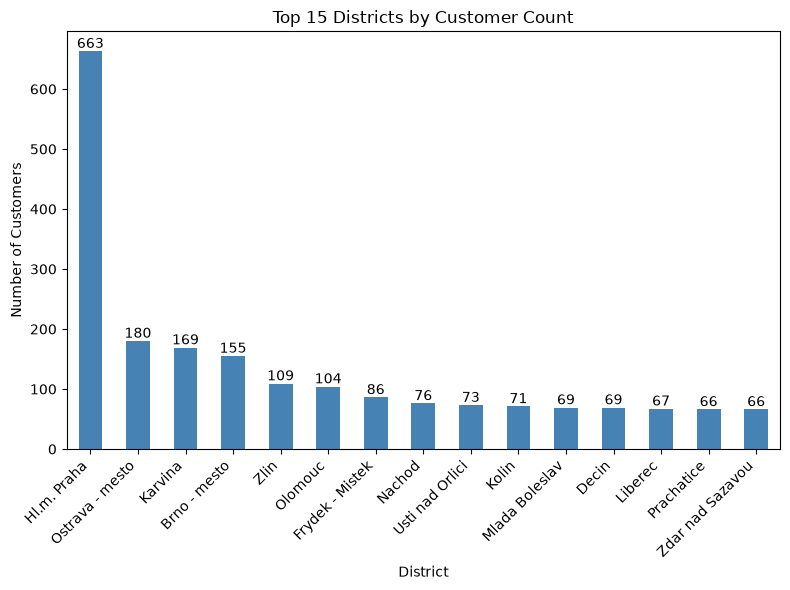

In [113]:
import matplotlib.pyplot as plt

customer_df = customer_distribution.sort_values(
    by="total_customers",
    ascending=False
).head(15)

ax = customer_df.plot(
    x="district_name",
    y="total_customers",
    kind="bar",
    figsize=(8,6),
    color="steelblue",
    legend=False
)

plt.title("Top 15 Districts by Customer Count")
plt.xlabel("District")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

### Business Insight

The analysis shows that customer concentration is uneven across districts. Hl.m. Praha has the highest number of customers (663), followed by Ostrava-mesto (180) and Karvina (169). 

This indicates that the bank's customer base is concentrated in a few key districts, while many other districts have significantly fewer customers. These high-customer districts represent important markets for customer retention, cross-selling, and future business growth.

### Customer Age Group Distribution

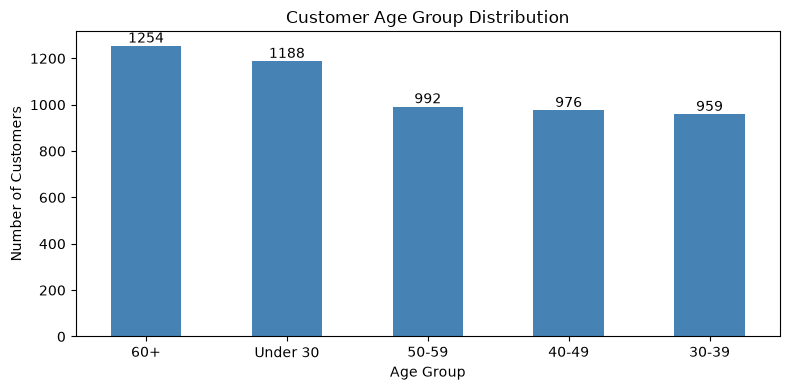

In [114]:
age_df = age_distribution.sort_values(
    by="total_customers",
    ascending=False
)

ax = age_df.plot(
    x="age_group",
    y="total_customers",
    kind="bar",
    figsize=(8,4),
    color="steelblue",
    legend=False
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

### Business Insight
The 60+ age group represents the largest customer segment (1,254), followed by Under 30 customers (1,188). Customer counts across the remaining age groups are relatively balanced, indicating that the bank serves a diverse customer base rather than relying on a single age segment. 

This distribution highlights opportunities to retain older customers while designing targeted products and marketing campaigns to strengthen engagement among younger age groups.

## 6.2 Loan Portfolio Validation

### Loan Distribution

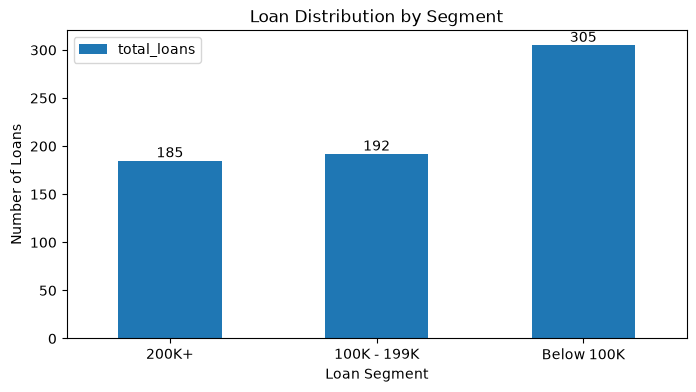

In [115]:
loan_portfolio.plot(
    x="loan_segment",
    y="total_loans",
    kind="bar",
    figsize=(8,4)
)

plt.title("Loan Distribution by Segment")
plt.xlabel("Loan Segment")
plt.ylabel("Number of Loans")

plt.xticks(rotation=0)

ax = plt.gca()

for container in ax.containers:
    ax.bar_label(container, fmt='%d')
    
plt.show()

### Business Insight

The chart confirms that most loans fall under the **Below 100K** segment, while the **100K–199K** and **200K+** segments contain fewer loans. This visualization validates the SQL finding that the bank's loan portfolio is concentrated in smaller loan amounts, providing a clear view of the overall loan distribution.

### Loan Repayment Status

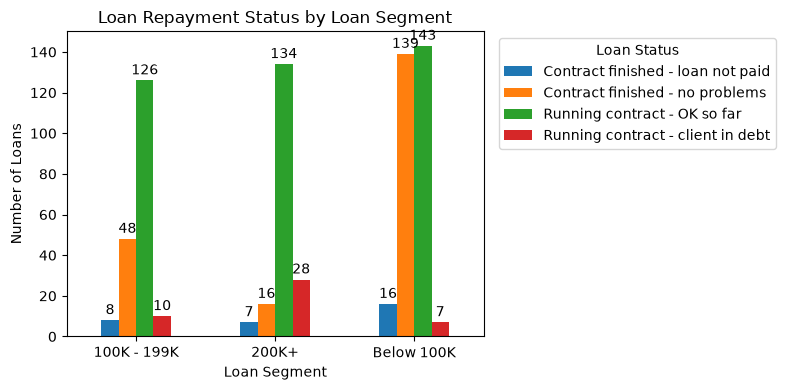

In [116]:
loan_pivot = loan_risk.pivot(
    index="loan_segment",
    columns="loan_status",
    values="total_loans"
)

ax = loan_pivot.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Loan Repayment Status by Loan Segment")
plt.xlabel("Loan Segment")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)

plt.legend(
    title="Loan Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

### Business Insight
Most loans across every loan segment are currently running without repayment issues, showing that the bank maintains a healthy and stable lending portfolio. While a small number of customers have entered debt or failed to repay after contract completion, these cases remain limited compared with the total active loans. 

This repayment pattern supports the earlier loan distribution analysis and indicates that, despite issuing loans across different value segments, the majority of borrowers continue to meet their repayment commitments. The smaller high-risk group can be monitored separately to reduce future credit losses.

## 6.3 Transaction Behaviour Validation

### Transaction Frequency Distribution

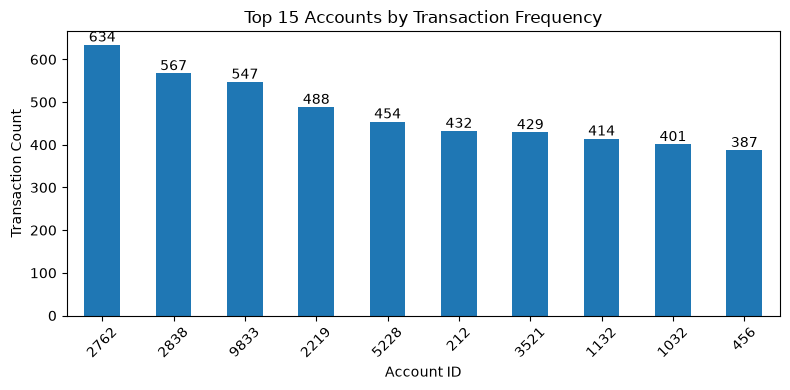

In [117]:
transaction_activity = transaction_activity.sort_values(
    by="transaction_count",
    ascending=False
).head(15)

ax = transaction_activity.plot(
    x="account_id",
    y="transaction_count",
    kind="bar",
    figsize=(8,4),
    legend=False
)

plt.title("Top 15 Accounts by Transaction Frequency")
plt.xlabel("Account ID")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0], fmt='%d')

plt.tight_layout()
plt.show()

### Business Insight 

The transaction frequency analysis shows that customer activity is concentrated among a small group of accounts. The most active account recorded 633 transactions, while the remaining top accounts generated between 387 and 567 transactions, indicating a gradual decline rather than a sharp difference in activity.

This distribution suggests that the bank has a stable base of highly engaged customers instead of relying on a single dominant account. Monitoring these high-activity accounts can help identify valuable customers, understand transaction behaviour, and support future retention and cross-selling strategies.

### Transaction Amount Distribution

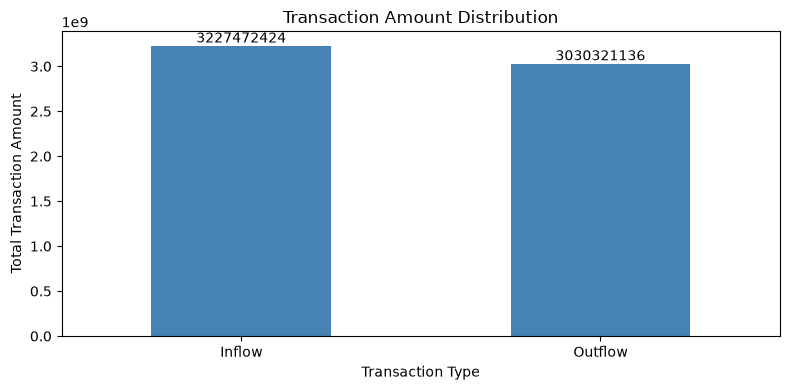

In [118]:
ax = money_flow.plot(
    x="flow_type",
    y="total_amount",
    kind="bar",
    figsize=(8,4),
    legend=False,
    color="steelblue"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.tight_layout()
plt.show()

### Business Insight

The transaction amount analysis shows that total inflow (3.23 billion) is slightly higher than total outflow (3.03 billion), indicating that the bank receives more funds than it disburses through customer transactions. The relatively small difference between the two values also reflects a balanced movement of money across the banking system.

This overall cash flow pattern suggests that customer accounts maintain healthy financial activity, with incoming funds largely supporting outgoing transactions. Maintaining this balance is important for ensuring liquidity, monitoring customer spending behaviour, and identifying unusual transaction trends when significant deviations occur.

### Transaction Share by Flow Type

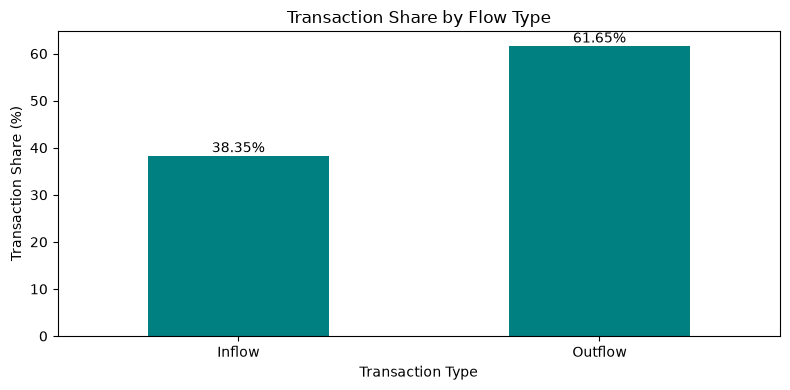

In [119]:
ax = money_flow.plot(
    x="flow_type",
    y="transaction_share",
    kind="bar",
    figsize=(8,4),
    legend=False,
    color="teal"
)

plt.title("Transaction Share by Flow Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Share (%)")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt='%.2f%%')

plt.tight_layout()
plt.show()

### Business Insight
The transaction share analysis reveals that outflow transactions account for 61.65% of all banking transactions, while inflow transactions contribute 38.35%. This indicates that customers perform more outgoing financial activities, reflecting frequent spending, transfers, and payment-related operations across their accounts.

Despite the higher proportion of outflow transactions, inflows remain substantial enough to support continuous account activity and maintain transaction stability. This balance suggests a healthy movement of funds within the banking system, enabling the bank to monitor customer behaviour, identify abnormal transaction patterns, and improve financial planning and risk management.

# 6.4 Customer Risk Validation

### High-Risk Customer Distribution

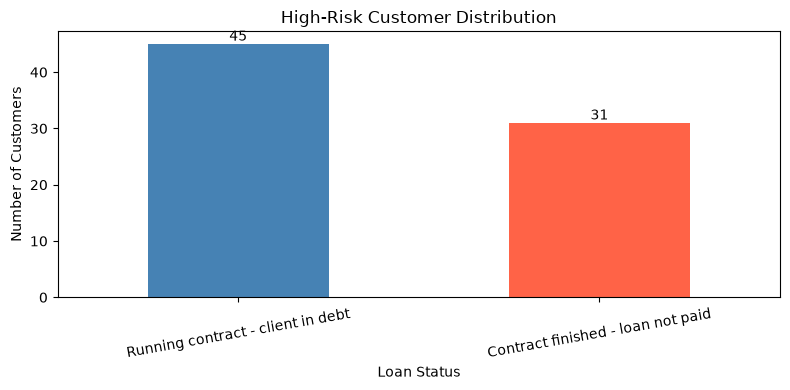

In [120]:
risk_status = high_risk_customers["loan_status"].value_counts()

ax = risk_status.plot(
    kind="bar",
    figsize=(8,4),
    color=["steelblue", "tomato"]
)

plt.title("High-Risk Customer Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)

ax.bar_label(ax.containers[0], fmt="%d")

plt.tight_layout()
plt.show()

### Business Insight

Customers with active loan repayments make up the largest share of the high-risk portfolio (45), showing that repayment risk is primarily concentrated among currently running loan contracts rather than only after loan closure. However, 31 customers have already completed their contracts without fully repaying the loan, indicating that unresolved debt continues beyond the loan lifecycle.

The presence of both ongoing repayment risk and unresolved default cases reinforces the need for separate monitoring strategies. Active borrowers require early warning and repayment tracking, while unpaid closed loans should be prioritised for recovery actions to minimise future credit losses.

## 6.5 Python Exploratory Data Analysis – Validation Summary

The Python Exploratory Data Analysis (EDA) complements the SQL analysis by visually validating the key business findings obtained from the Berka Banking dataset. While SQL answers the business questions through structured queries, Python strengthens those findings using charts and statistical summaries, making customer behaviour, loan portfolio, transaction activity, and customer risk patterns easier to interpret.

The analysis is organised into four validation sections: Customer Behaviour Validation, Loan Portfolio Validation, Transaction Behaviour Validation, and Customer Risk Validation. Each section uses visualizations to confirm that the patterns identified during SQL analysis are consistent across the dataset and provides additional business context to support data-driven decision making.

Overall, the Python validation confirms the reliability of the SQL results and provides clear visual evidence that can assist banking stakeholders in customer segmentation, lending strategy, transaction monitoring, and risk management.

# 7. Final Key Findings

1. The customer age distribution shows that the 60+ age group represents the largest customer segment with 1,254 customers, followed by Under 30 (1,188), 50–59 (992), 40–49 (976), and 30–39 (959).

2. Loan portfolio analysis confirms that the bank's lending is concentrated in the Below 100K segment with 305 loans, followed by the 100K–199K segment (192 loans) and the 200K+ segment (185 loans).

3. Loan repayment analysis indicates that the majority of borrowers are currently in the "Running contract – OK so far" status across all loan segments, while only a smaller number of customers are classified as "Client in debt" or "Loan not paid", reflecting an overall healthy repayment pattern.

4. Transaction frequency analysis shows that customer activity is concentrated among a limited number of accounts. The most active account recorded 634 transactions, while the remaining top accounts recorded between 387 and 567 transactions.

5. Transaction amount analysis shows that the total inflow amount is 3,227,472,424, which is slightly higher than the total outflow amount of 3,030,321,136, indicating balanced movement of funds across the banking system.

6. Transaction share analysis reveals that Outflow transactions account for 61.65% of total transaction activity, while Inflow transactions contribute 38.35%, showing that outgoing transactions occur more frequently than incoming transactions.

7. Customer risk analysis identified only 76 high-risk customers in total, consisting of 45 customers with "Running contract – client in debt" status and 31 customers with "Contract finished – loan not paid" status, representing a relatively small high-risk portfolio.

8. Python Exploratory Data Analysis (EDA) successfully validated all major SQL analysis results through visualizations, confirming that the business findings related to customer distribution, loan portfolio, transaction behaviour, and customer risk are consistent across the dataset.

# 8. Business Recommendations

1. The strong presence of customers aged 60+ creates an opportunity to introduce financial products and services designed for senior customers.

2. Since the Below 100K segment contains the highest number of loans, maintaining regular portfolio reviews will help identify changes in repayment performance at an early stage.

3. Early monitoring of customers with outstanding repayments may reduce the likelihood of loans moving into long-term default categories.

4. Periodic review of highly active customer accounts provides better visibility into transaction behaviour and supports the identification of unusual activity.

5. Regular tracking of inflow and outflow transactions strengthens cash flow monitoring and provides a clearer understanding of overall banking activity.

6. Customers with a consistent repayment history represent a valuable group for future lending opportunities and long-term relationship development.

# 9. Final Summary

The project presented a complete end-to-end analysis of the Berka Banking dataset using SQL and Python. The analysis began with data validation and preparation to ensure data quality before exploring customer behaviour, loan portfolio performance, transaction activity, and customer risk.

SQL was used to answer key business questions by combining multiple banking tables, performing aggregations, and identifying meaningful business patterns. These findings were then validated through Python Exploratory Data Analysis (EDA), where visualizations confirmed the consistency of the SQL results and provided additional business context.

The analysis showed that customers aged 60+ represent the largest customer segment, the Below 100K loan category contains the highest number of loans, most borrowers maintain healthy repayment behaviour, transaction activity remains stable with balanced cash flow, and only a relatively small group of customers falls into high-risk loan categories.

Overall, the project demonstrates how SQL and Python can work together to transform raw banking data into meaningful business insights. The findings provide valuable support for customer segmentation, loan portfolio evaluation, transaction monitoring, and customer risk assessment, enabling more informed business decisions through data-driven analysis.